# Demo to use the Stretcher object

## Utils for this notebook
### Modules

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from coodddaaaa.stretching import Stretcher 
from coodddaaaa.utils import Timer, polyspace
from coodddaaaa.butter import BandpassFilter
from coodddaaaa.utils import TukeyWindow

### Parameters

In [2]:
dt = 1e-6  # sampling, sec
nt = 512   # number of samples in time
t0 = -1e-5   # start time in sec

time_array = t0 + np.arange(nt) * dt  # seconds  (NEVER use np.linspace for time vectors)
fnyquist = 0.5 / dt    # Hz

tmin = 1e-4   # begin of time window in sec
tmax = 4e-4   # end of time window in sec
fmin = 0.1 * fnyquist   # lower freq Hz
fmax = 0.5 * fnyquist   # upper freq Hz

eps_true = 0.00123456789  # the imposed stretching coeff

# epsilon search grid
eps_search_min = -0.01  # min epsilon value
eps_search_max = +0.01  # max epsilon value
n_eps = 100  # number of epsilon values to test
eps_pw = 2.0  # power gain, 1 means linear spacing of the eps grid, > 1 means polynomial distribution of the grid

noise_level = 0.5

In [3]:
# create the time taper
win = TukeyWindow(tmin-0.1*(tmax-tmin), tmin, tmax, tmax+0.1*(tmax-tmin))
taper = win(t0 + np.arange(nt) * dt)

# and the bandpass filter
bandpass = BandpassFilter(freqmin=fmin, freqmax=fmax, order=4, sampling_rate=1./dt)

## Case 1 : Find the best stretching between a reference and another signal

### Step1 : generate the reference and stretched signals

In [4]:
# Build the reference band-pass / tapered coda
y_reference = bandpass(np.random.randn(nt), zerophase=True) * taper


In [5]:
# Build the observed signal, a stretched version of it + noise
stretcher0 = Stretcher(t0=t0, nt=nt, dt=dt, eps=np.array([eps_true]), norm=False)  # for stretching only
y_observed = stretcher0.stretch(y_reference)[0, :]  # only one trace here
y_observed += bandpass(np.random.randn(nt) * noise_level) * taper  # add noise in the bandwidth only

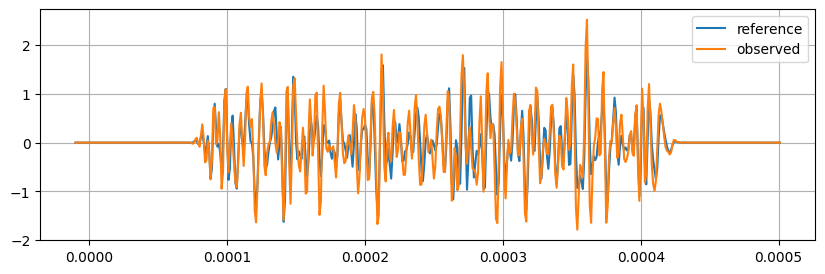

In [6]:
# Display
plt.figure(figsize=(10, 3))
plt.plot(time_array, y_reference, label="reference")
plt.plot(time_array, y_observed, label="observed");
plt.gca().legend();
plt.gca().grid(True)

### Step2 : Pre-compute the stretched versions of the reference

In [7]:
# Build the stretching basis of the reference signal

# epsilon search grid
eps_search = polyspace(eps_search_min, eps_search_max, n_eps, eps_pw)

# Build the stretcher object for correlation this time 
# (do not use stretcher0 which is not normalized)
# Most costly operations are performed here, once for all
with Timer('Build the stretcher object'):
    stretcher = Stretcher(t0=t0, nt=nt, dt=dt, eps=eps_search, norm=True, interp_kind="fourier")  

with Timer('Compute the stretched reference basis'):
    y_reference_stretched = stretcher.stretch(y_reference)


Timer[Build the stretcher object]: 566.27 ms
Timer[Compute the stretched reference basis]: 7.85 ms


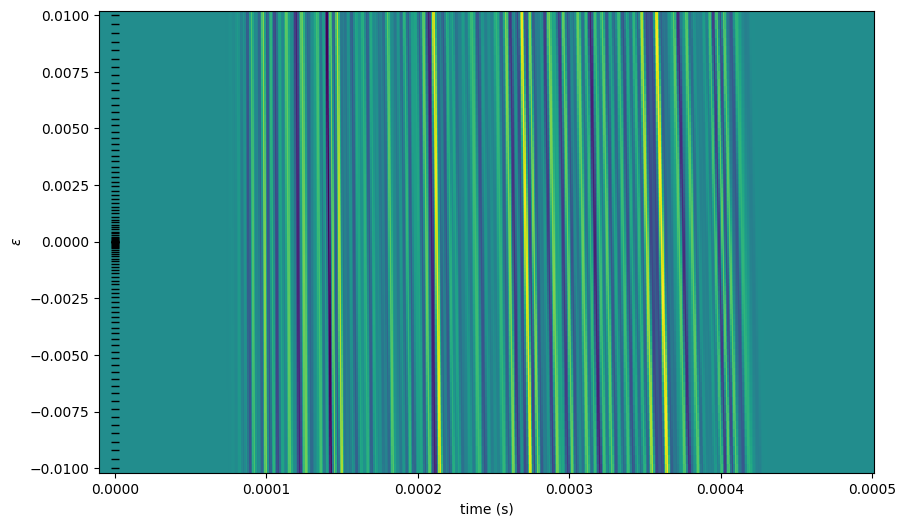

In [8]:
# Display
plt.figure(figsize=(10, 6))
plt.gca().set_xlabel('time (s)')
plt.gca().set_ylabel('$ \epsilon $')
plt.pcolormesh(stretcher.t, stretcher.eps, y_reference_stretched, shading="auto");
plt.gca().plot(eps_search * 0, eps_search, "k_"); # show the epsilon grid as ticks on yaxis

### Step 3: Correlation of the observed signal with the reference

In [9]:
# Correlate observed with reference
with Timer('Normalized correlation'):
    c = stretcher.corr(y_observed, y_reference_stretched)  # correlation function, 1d, shape (neps, )

with Timer('Find the max of correlation with subsamp precision'):
    eps_max, c_max = stretcher.corrmax(c)  # 2 floats
    
with Timer('Compute Uncertainty'):
    eps_unc = stretcher.stretching_uncertainty(
        c_max, fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax)  # float
    

Timer[Normalized correlation]: 0.56 ms
Timer[Find the max of correlation with subsamp precision]: 0.10 ms
Timer[Compute Uncertainty]: 0.02 ms


### Results

In [10]:
print(f"expected stretching: {eps_true=}")
print(f"obtained stretching: {eps_max=}")
print(f"estimated stretching uncertainty: {eps_unc=}")
print(f"normalized correlation coefficient: {c_max=}")

expected stretching: eps_true=0.00123456789
obtained stretching: eps_max=0.0012926486735236435
estimated stretching uncertainty: eps_unc=0.00013782007294207383
normalized correlation coefficient: c_max=0.8841901421253725


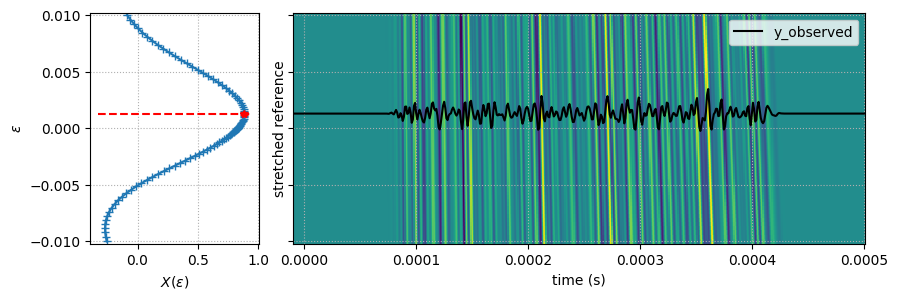

In [11]:
# Display
fig = plt.figure(figsize=(10, 3))
gs = fig.add_gridspec(1, 4)

ax1 = plt.subplot(gs[0, 0], xlabel=r"$ X(\epsilon) $", ylabel="$ \epsilon $")
ax2 = plt.subplot(gs[0, 1:], sharey=ax1, xlabel="time (s)", ylabel="stretched reference")
plt.setp(ax2.get_yticklabels(), visible=False)

ax1.plot(c, stretcher.eps, '+-')
ax1.grid(True, linestyle=":")

ax1.plot(c_max, eps_max, "r*")
ax1.plot([c_max, c_max], [eps_max-eps_unc, eps_max+eps_unc], "r_-")
ax1.plot(ax1.get_xlim(), [eps_max, eps_max], 'r--')

ax2.pcolormesh(stretcher.t, stretcher.eps, y_reference_stretched, shading="auto");
ax2.plot(time_array, 0.0005 * y_observed / np.std(y_observed) + eps_max, 'k', label="y_observed")
ax2.grid(True, linestyle=":")
plt.legend();

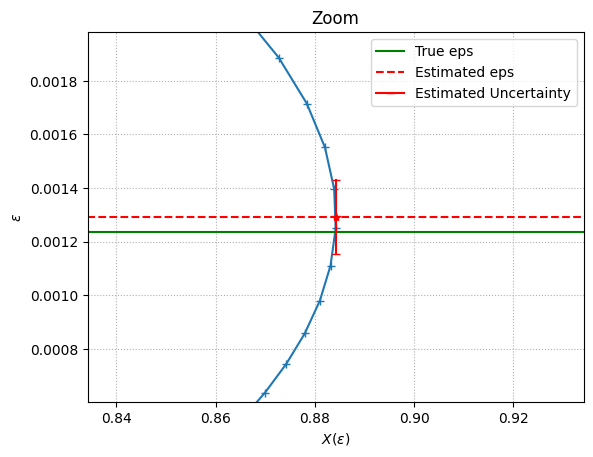

In [12]:
# ZOOM IN
plt.gca().set_title('Zoom')
plt.plot(c, stretcher.eps, '+-')
plt.grid(True, linestyle=":")

plt.plot(ax1.get_xlim(), [eps_true, eps_true], 'g-', label="True eps")

plt.plot(c_max, eps_max, "r*")
plt.plot(ax1.get_xlim(), [eps_max, eps_max], 'r--', label="Estimated eps")

plt.plot([c_max, c_max], [eps_max-eps_unc, eps_max+eps_unc], "r_-", label="Estimated Uncertainty")
plt.gca().set_xlabel(r"$ X(\epsilon) $")
plt.gca().set_ylabel(r"$ \epsilon $")

plt.gca().set_xlim((c_max - 0.05, c_max + 0.05))
plt.gca().set_ylim((eps_max - 5 * eps_unc, eps_max + 5 * eps_unc))
plt.gca().legend();

# Case 2 : Find the stretching history in a b-scan using a single reference

### Step 1 : Generate a b-scan with varying stretching as a function of time

In [13]:
# Genereate a synthetic stretching history
n_traces = 256  # number of traces

eps_history = np.linspace(0., 0.002, n_traces)
eps_history += 0.0003 * np.sin(2. * np.pi * np.arange(n_traces) / 150)

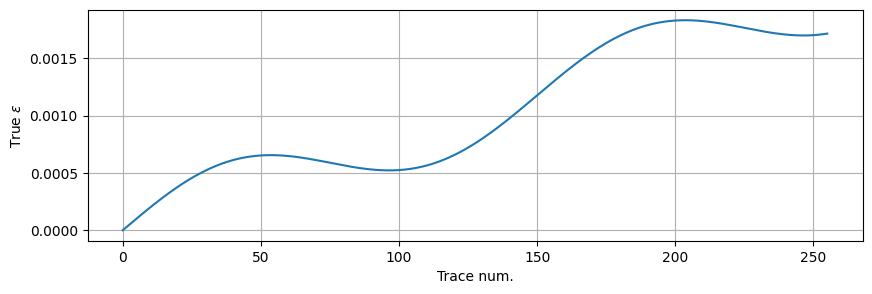

In [14]:
plt.figure(figsize=(10, 3))
plt.gca().set_ylabel('True $ \epsilon $')
plt.gca().set_xlabel('Trace num.')
plt.plot(eps_history)
plt.gca().grid(True)

In [15]:
# Build the synthetic bscan by stretching the reference, add noise
with Timer('Build the stretcher to generate the bscan'):
    stretcher0 = Stretcher(nt=nt, dt=dt, t0=t0, eps=eps_history, norm=False, interp_kind="cubic")

with Timer('Generate the bscan'):
    bscan = stretcher0.stretch(y_reference)

bscan += bandpass(np.random.randn(n_traces, nt) * noise_level)
bscan *= taper


Timer[Build the stretcher to generate the bscan]: 54.99 ms
Timer[Generate the bscan]: 2.49 ms


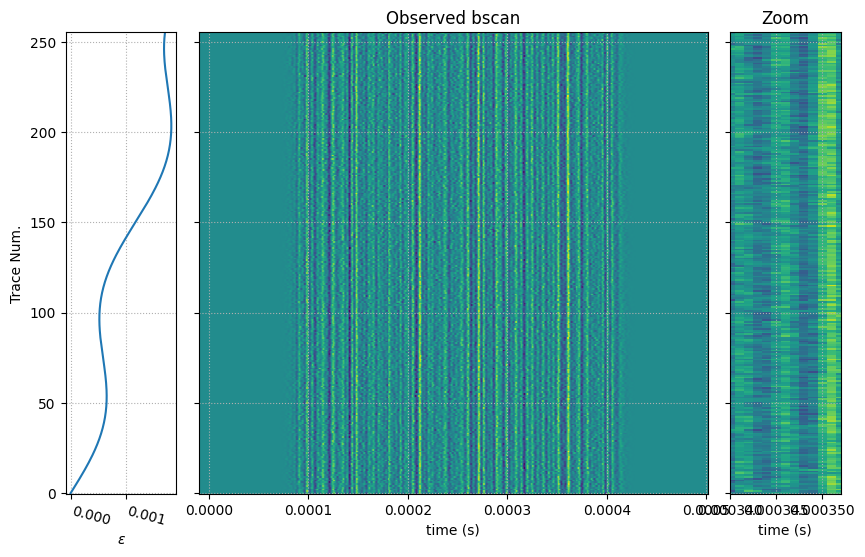

In [16]:
# Display
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 6)

ax1 = plt.subplot(gs[0, 0], xlabel=r"$ \epsilon $", ylabel="Trace Num.")
ax2 = plt.subplot(gs[0, 1:-1], sharey=ax1, xlabel="time (s)", title="Observed bscan")
ax3 = plt.subplot(gs[0, -1], sharey=ax1, xlabel="time (s)", title="Zoom")

plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax1.plot(eps_history, np.arange(n_traces), '-')
plt.setp(ax1.get_xticklabels(), ha="left", rotation=-15)
ax2.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");

ax3.pcolormesh(stretcher.t, np.arange(n_traces), bscan, shading="auto");
ax3.set_xlim(tmin + 0.8 * (tmax - tmin), tmin + 0.84 * (tmax - tmin))

ax1.grid(True, linestyle=":")
ax2.grid(True, linestyle=":");
ax3.grid(True, linestyle=":");

### Step 2 : Pre-compute the stretched versions of the reference

In [17]:
# Choose a reference signal in the bscan (first trace)
i_reference = 0
y_reference = bscan[i_reference, :]   # so that the reference also includes noise
assert eps_history[i_reference] == 0.

In [18]:
# Build the stretching basis of the reference signal

# epsilon search grid
eps_search = polyspace(eps_search_min, eps_search_max, n_eps, eps_pw)

# for correlation this time (do not use stretcher0)
with Timer('Build the stretcher object'):
    stretcher = Stretcher(t0=t0, nt=nt, dt=dt, eps=eps_search, norm=True, interp_kind="cubic")  

with Timer('Compute the stretched reference basis'):
    y_reference_stretched = stretcher.stretch(y_reference)  # compute the stretching basis of the reference

Timer[Build the stretcher object]: 22.82 ms
Timer[Compute the stretched reference basis]: 1.68 ms


In [19]:
# Display (same as above)
if False:
    plt.figure(figsize=(10, 6))
    plt.gca().set_xlabel('time (s)')
    plt.gca().set_ylabel('$ \epsilon $')
    plt.pcolormesh(stretcher.t, stretcher.eps, y_reference_stretched, shading="auto");
    plt.gca().plot(eps_search * 0, eps_search, "k_"); # show the epsilon grid as ticks on yaxis

### Step 3 : correlate all signals of the bscan with the reference

In [20]:
# Correlate all traces to the reference
with Timer(f'Correlate and find maxima in a bscan of {n_traces} traces with a single reference'):
    c = stretcher.corr(bscan, y_reference_stretched)
    eps_max_history, c_max_history = stretcher.corrmax(c)
    eps_unc_history = stretcher.stretching_uncertainty(
        cmax=c_max_history, fmin=fmin, fmax=fmax, tmin=tmin, tmax=tmax)


Timer[Correlate and find maxima in a bscan of 256 traces with a single reference]: 14.99 ms


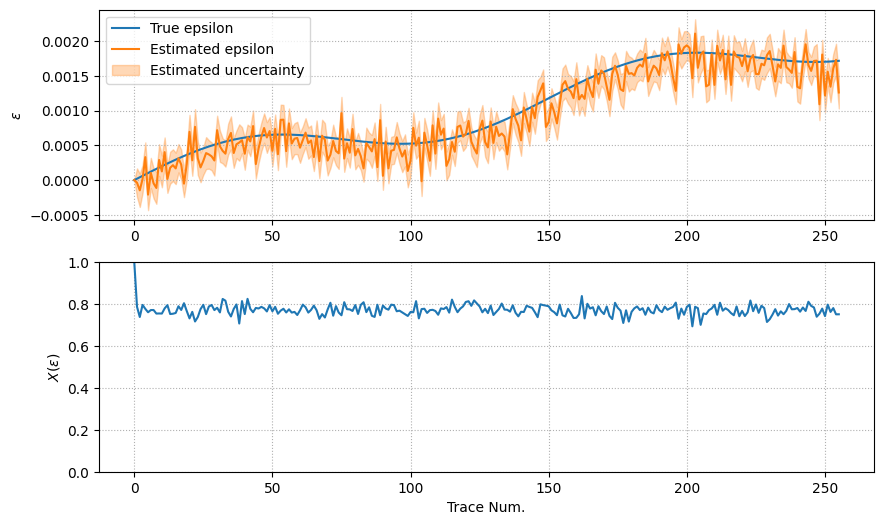

In [21]:
# Display
plt.figure(figsize=(10, 6))

plt.subplot(211, ylabel="$ \epsilon $")
plt.plot(np.arange(n_traces), eps_history, label="True epsilon")
hdl, = plt.plot(np.arange(n_traces), eps_max_history, label="Estimated epsilon")
plt.gca().fill_between(
    x=np.arange(n_traces), 
    y1=eps_max_history-eps_unc_history, 
    y2=eps_max_history+eps_unc_history,
    color=hdl.get_color(), alpha=0.3,
    label="Estimated uncertainty")   
plt.gca().legend()
plt.gca().grid(True, linestyle=":")

plt.subplot(212, sharex=plt.gca(), ylabel="$ X(\epsilon) $")
plt.plot(np.arange(n_traces), c_max_history);
plt.gca().set_ylim(0., 1.)
plt.gca().set_xlabel("Trace Num.")
plt.gca().grid(True, linestyle=":")

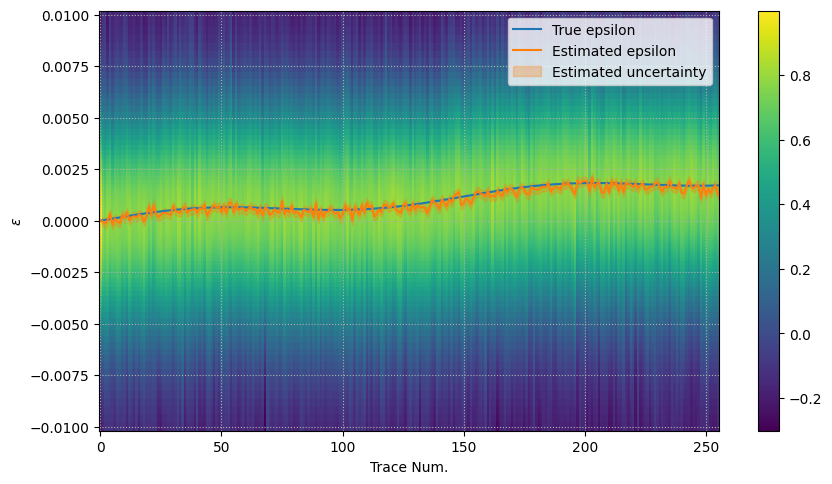

In [22]:
# Display the full correlation function to track possible cycle skip effects when the stretching is 
# very strong relative to the time period in the late coda part
plt.figure(figsize=(10, 12))

plt.subplot(211, ylabel="$ \epsilon $", xlabel="Trace Num.")
plt.colorbar(plt.pcolormesh(np.arange(n_traces), stretcher.eps, c, shading="auto"))
plt.plot(np.arange(n_traces), eps_history, label="True epsilon")
hdl, = plt.plot(np.arange(n_traces), eps_max_history, label="Estimated epsilon")
plt.gca().fill_between(
    x=np.arange(n_traces), 
    y1=eps_max_history-eps_unc_history, 
    y2=eps_max_history+eps_unc_history,
    color=hdl.get_color(), alpha=0.3,
    label="Estimated uncertainty")   
plt.gca().legend()
plt.gca().grid(True, linestyle=":")


# Case 3 : Find the stretching history in a b-scan without any reference
(under development): The approach is similar to Brenguier et al., 2014 (supp. mat.) except that we consider that solving a least square inverse problem is not necessary to infer the stretching history from the cross-stretching matrix as the problem is well posed.

We note $ y_i(t) $  the signal measured at calendar time $ T_i $.  
The stretching correlation function is defined following Weaver et al., 2011 :

$$ 
\left\{ y_i, y_j \right\}(\varepsilon) = 
X_{ij}(\varepsilon) = 
\frac
    {\int y_i(t \times (1+\varepsilon)) . y_j(t) \, dt }
    {\sqrt{
        \int y_i^2(t) \, dt 
        \int y_j^2(t) \, dt }}
$$

The stretching coefficient matrix gives the best stretching coefficient for each pair of times $Ti,Tj$

$$
\varepsilon_{ij} = argmax[X_{ij}(\varepsilon)]
$$

The correlation coefficient matrix is the maximum of the normalized stretching correlation for each pair of times $Ti,Tj$

$$
C_{ij} = X_{ij}(\varepsilon_{ij})
$$

If the source is stable in time, 
the signals at calendar times $ T_i $ and $ T_j $ 
are two stretched version of the same reference $ u_0 $, thus  

$$
\left\{
\begin{aligned}
y_i(t) &= u_0(t \times (1 + \varepsilon^{true}(T_i))  \\
y_j(t) &= u_0(t \times (1 + \varepsilon^{true}(T_j)) \\
\end{aligned}
\right.
$$

Then, one can show that   

$$
X_{ij}(\varepsilon) \approx \left\{ u_0, u_0 \right\}\left(\varepsilon + \varepsilon^{true}(T_{i}) - \varepsilon^{true}(T_{j}) + \mathcal{O}(\varepsilon^{2})\right)
$$

As the auto-stretching-correlation of $u_0$ peaks at $\varepsilon=0$, then 

$$
\varepsilon_{ij} = argmax [X_{ij}] \approx \varepsilon^{true}(T_{j}) - \varepsilon^{true}(T_{i}) + \mathcal{O}(\varepsilon^{2})
$$

The zero-mean stretching history can be obtained by averaging vertically (or horizontally) the stretching matrix :  

$$ 
\varepsilon^{true}(T_{j}) - \left< \varepsilon^{true} \right> \approx \frac{1}{N} \sum_{i=0}^{N-1} \varepsilon_{ij} 
$$

One can improve this averaging by weighting the stretching measurements by the correlation coefficients (no Einstein summation)

$$ 
\varepsilon^{true}(T_{j}) - \left< \varepsilon^{true} \right> \approx \frac {\sum_{i=0}^{N-1} C_{ij}^\gamma \times \varepsilon_{ij} } {\sum_{i=0}^{N-1} C_{ij}^\gamma } 
$$

where $ \gamma $ is a power coefficient used to increase the weight of the best fitting pairs of correlation functions

### Compute the stretching and correlation matrices

In [23]:
with Timer('Correlate all pairs of traces in the bscan'):
    c_triu, e_triu = stretcher.corr_all_with_all(bscan)
    
# convert to square arrays
c2d = stretcher.triu2dense(c_triu, symetric=True, diag=1)
e2d = stretcher.triu2dense(e_triu, symetric=False, diag=0)

Timer[Correlate all pairs of traces in the bscan]: 1854.70 ms


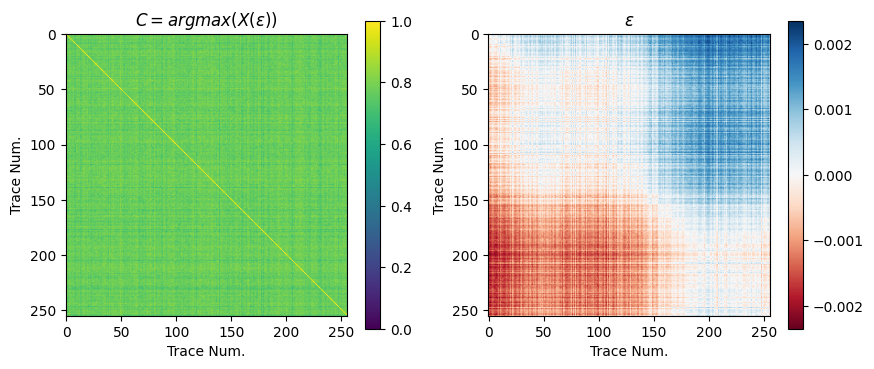

In [24]:
# Display
plt.figure(figsize=(10, 4))

plt.subplot(121, title="$ C=argmax ( X(\epsilon) ) $", xlabel="Trace Num.", ylabel="Trace Num.")
plt.colorbar(
    plt.imshow(c2d, 
               vmin=0., vmax=1.0, 
               cmap=plt.get_cmap('viridis')))

plt.subplot(122, title="$ \epsilon $", xlabel="Trace Num.", ylabel="Trace Num.")
plt.colorbar(
    plt.imshow(
        e2d, 
        vmin=-np.abs(e2d).max(),
        vmax=+np.abs(e2d).max(),
        cmap=plt.get_cmap('RdBu'))
    );

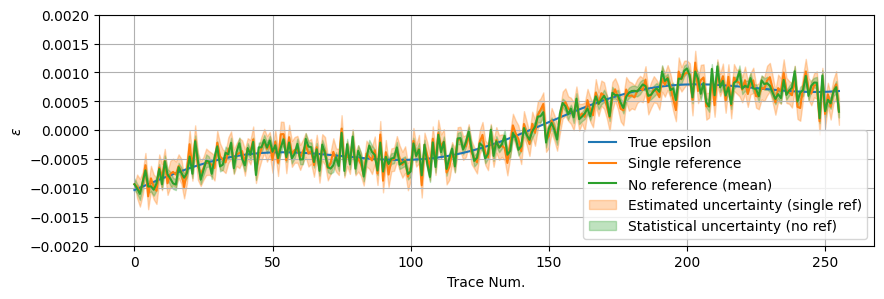

In [25]:
# recover the stretching history
eps_mean_history = (e2d - e2d.mean(axis=1)[:, np.newaxis]).mean(axis=0)
eps_std_history = np.std(e2d - e2d.mean(axis=1)[:, np.newaxis], axis=0)

plt.figure(figsize=(10, 3))
plt.plot(eps_history - eps_history.mean(), label="True epsilon")

# replot single reference version
hdl, = plt.plot(eps_max_history - eps_max_history.mean(), label="Single reference")
plt.fill_between(
    x=np.arange(len(eps_max_history)), 
    y1=eps_max_history- eps_max_history.mean()-eps_unc_history , 
    y2=eps_max_history- eps_max_history.mean()+eps_unc_history , 
    color=hdl.get_color(), alpha=0.3, label="Estimated uncertainty (single ref)")

# add results for this section
hdl, = plt.plot(eps_mean_history, label="No reference (mean)")
#hdl, = plt.plot(emed, label="No reference (median)")
plt.fill_between(
    x=np.arange(len(eps_mean_history)), 
    y1=eps_mean_history-eps_std_history, 
    y2=eps_mean_history+eps_std_history, 
    color=hdl.get_color(), 
    alpha=0.3, label="Statistical uncertainty (no ref)")

plt.gca().set_xlabel("Trace Num.")
plt.gca().set_ylabel("$ \epsilon $")
plt.gca().legend();
plt.gca().set_ylim(-0.002, 0.002)
plt.grid(True);